In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
#DEFINING PATHS
train_images = "../data/brisc2025/segmentation_task/train/images"
train_masks = "../data/brisc2025/segmentation_task/train/masks"

In [3]:
#check no of images
print("Train Images:", len(os.listdir(train_images)))#this will give no of images inside train_images
print("Train Masks:", len(os.listdir(train_masks)))#this will give no of masks inside train_masks

Train Images: 3933
Train Masks: 3933


In [4]:
#get one sample file name
img_name = os.listdir(train_images)[0]
print(img_name)

brisc2025_train_00001_gl_ax_t1.jpg


In [5]:
#inspecting the mask names
print(os.listdir(train_masks)[:5])

['brisc2025_train_00001_gl_ax_t1.png', 'brisc2025_train_00002_gl_ax_t1.png', 'brisc2025_train_00003_gl_ax_t1.png', 'brisc2025_train_00004_gl_ax_t1.png', 'brisc2025_train_00005_gl_ax_t1.png']


In [6]:
#also inspecting the image names
print(os.listdir(train_images)[:5])

['brisc2025_train_00001_gl_ax_t1.jpg', 'brisc2025_train_00002_gl_ax_t1.jpg', 'brisc2025_train_00003_gl_ax_t1.jpg', 'brisc2025_train_00004_gl_ax_t1.jpg', 'brisc2025_train_00005_gl_ax_t1.jpg']


In [7]:
# Load a sample image and its corresponding mask (label)
# Convert image filename (.jpg) to mask filename (.png) for correct pairing

img = Image.open(os.path.join(train_images, img_name))
mask_name = img_name.replace(".jpg", ".png")
mask = Image.open(os.path.join(train_masks, mask_name))

(-0.5, 511.5, 511.5, -0.5)

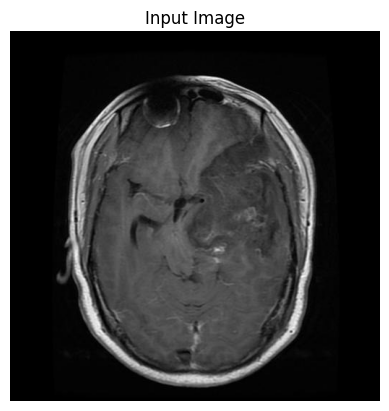

In [8]:
# Display the input image (medical scan)
plt.imshow(img)#we are showing the image we loaded
plt.title("Input Image")
plt.axis("off")

(-0.5, 511.5, 511.5, -0.5)

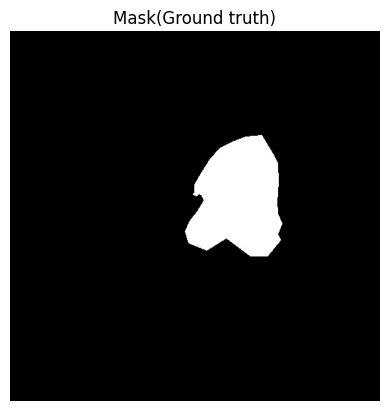

In [9]:
# Display the corresponding mask (ground truth->tumor regions)
plt.imshow(mask, cmap='gray')#we are showing the mask we loaded
plt.title("Mask(Ground truth)")
plt.axis("off")

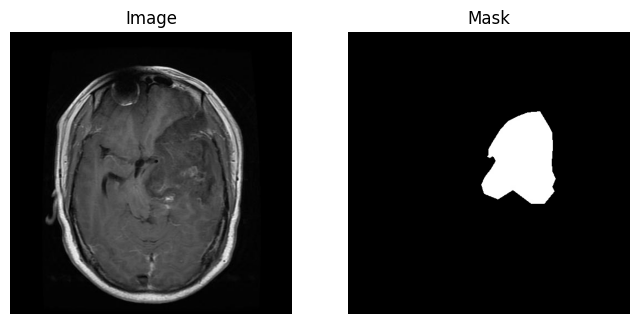

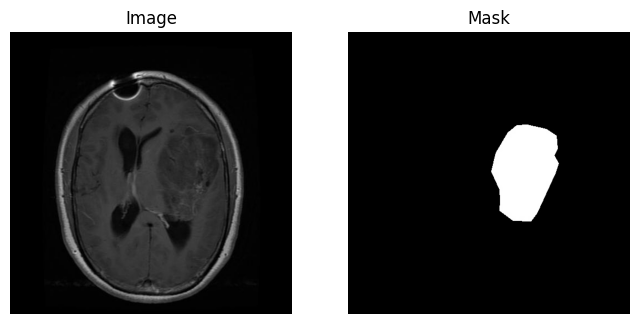

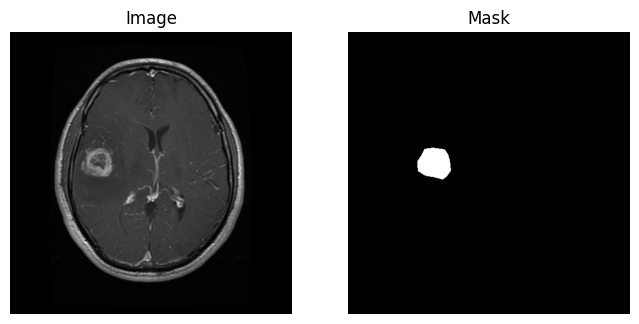

In [10]:
# Display multiple image-mask pairs to verify dataset consistency
for i in range(3):
    img_name = os.listdir(train_images)[i]
    img = Image.open(os.path.join(train_images, img_name))
    # Convert image name to mask name (.jpg → .png)
    mask_name = img_name.replace(".jpg",".png")
    mask = Image.open(os.path.join(train_masks,mask_name))

    plt.figure(figsize=(8,4))
    
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Image")
    plt.axis('off')
    
    plt.subplot(1,2,2)
    plt.imshow(mask, cmap='gray')
    plt.title("Mask")
    plt.axis('off')
    
    plt.show()

In [11]:
#checking the image properties
print("Image size: ",img.size)
print("Mask size: ",mask.size)

Image size:  (512, 512)
Mask size:  (512, 512)


- Dataset contains 3933 training images
- Images and masks are correctly paired
- Image and mask sizes are same
- Masks are binary (black & white)

## Dataset Integrity Check — Train vs Test Overlap Analysis

This section verifies whether the train and test sets contain any duplicate images.
Three levels of checking are performed:

### Check 1 — Filename Comparison
Compares filenames between train and test folders.
Result: 0 common filenames → train and test filenames are completely different.

### Check 2 — Simple Image Hash (Grayscale, 64x64)
Compares image content using a lightweight hash (grayscale, resized to 64x64).
Result: 98 potential duplicates found — requires further verification.

### Check 3 — Accurate Image Hash (Full Color, Original Size)
Compares full-resolution color image content using precise hashing.
Result: 98 confirmed duplicate images found in both train and test sets.

### Key Findings:
- Total train images : 3933
- Total test images  : 860
- Duplicate images   : 98 (all from Meningioma category)
- Unique test images : 762 (88.6% completely unseen)

### Conclusion:
The BRISC 2025 dataset contains 98 images (11.4% of test set) that appear in 
both train and test folders with different filenames. All duplicates belong to 
the Meningioma (me) category. This is a minor data leakage issue in the dataset 
itself — not in our implementation. Our test results may be slightly optimistic 
by a small margin due to this overlap.

In [12]:
## to check whether train and test have same images or different (both folder contain same or different)

import os

# Get all filenames from train and test folders
train_files = set(os.listdir(train_images))  # using already defined path
test_files  = set(os.listdir("../data/brisc2025/segmentation_task/test/images"))

# Find common files between train and test
common_files = train_files.intersection(test_files)

print(f"Total train images : {len(train_files)}")
print(f"Total test images  : {len(test_files)}")
print(f"Common images      : {len(common_files)}")

if len(common_files) == 0:
    print("Train and test sets are COMPLETELY DIFFERENT!")
else:
    print("Some images appear in both sets!")
    print("First 5 common files:", list(common_files)[:5])

Total train images : 3933
Total test images  : 860
Common images      : 0
✅ Train and test sets are COMPLETELY DIFFERENT!


In [13]:
import cv2
import numpy as np
import os

train_path = "../data/brisc2025/segmentation_task/train/images"
test_path  = "../data/brisc2025/segmentation_task/test/images"

train_files = os.listdir(train_path)
test_files  = os.listdir(test_path)

print("Calculating image hashes...")

# Calculate a hash for each image
# Same image = same hash, different image = different hash
def get_image_hash(filepath):
    img = cv2.imread(filepath, 0)  # load as grayscale
    img = cv2.resize(img, (64, 64))  # resize to small size
    return hash(img.tobytes())  # convert to hash

# Get hashes for all train images
print("Hashing train images...")
train_hashes = set()
for f in train_files:
    h = get_image_hash(os.path.join(train_path, f))
    train_hashes.add(h)

# Get hashes for all test images
print("Hashing test images...")
test_hashes = set()
for f in test_files:
    h = get_image_hash(os.path.join(test_path, f))
    test_hashes.add(h)

# Find common hashes
common = train_hashes.intersection(test_hashes)

print(f"\nTrain unique images : {len(train_hashes)}")
print(f"Test unique images  : {len(test_hashes)}")
print(f"Common images       : {len(common)}")

if len(common) == 0:
    print(" Images are COMPLETELY DIFFERENT — no duplicates!")
else:
    print(f" {len(common)} identical images found in both sets!")

Calculating image hashes...
Hashing train images...
Hashing test images...

Train unique images : 3904
Test unique images  : 853
Common images       : 98
⚠️ 98 identical images found in both sets!


In [14]:
import cv2
import numpy as np
import os

train_path = "../data/brisc2025/segmentation_task/train/images"
test_path  = "../data/brisc2025/segmentation_task/test/images"

train_files = os.listdir(train_path)
test_files  = os.listdir(test_path)

# Use more accurate hashing method
def get_accurate_hash(filepath):
    img = cv2.imread(filepath)  # load full color
    if img is None:
        return None
    return hash(img.tobytes())  # hash full image bytes

print("Hashing train images...")
train_hash_to_file = {}
for f in train_files:
    h = get_accurate_hash(os.path.join(train_path, f))
    train_hash_to_file[h] = f

print("Hashing test images...")
test_hash_to_file = {}
for f in test_files:
    h = get_accurate_hash(os.path.join(test_path, f))
    test_hash_to_file[h] = f

# Find common
common_hashes = set(train_hash_to_file.keys()).intersection(set(test_hash_to_file.keys()))

print(f"\nCommon images found: {len(common_hashes)}")

if len(common_hashes) == 0:
    print("✅ Images are COMPLETELY DIFFERENT!")
else:
    print("⚠️ Duplicate images found!")
    print("\nFirst 5 duplicates:")
    for h in list(common_hashes)[:5]:
        print(f"   Train: {train_hash_to_file[h]}")
        print(f"   Test:  {test_hash_to_file[h]}")
        print()

Hashing train images...
Hashing test images...

Common images found: 98
⚠️ Duplicate images found!

First 5 duplicates:
   Train: brisc2025_train_01293_me_ax_t1.jpg
   Test:  brisc2025_test_00304_me_ax_t1.jpg

   Train: brisc2025_train_01281_me_ax_t1.jpg
   Test:  brisc2025_test_00289_me_ax_t1.jpg

   Train: brisc2025_train_02008_me_sa_t1.jpg
   Test:  brisc2025_test_00485_me_sa_t1.jpg

   Train: brisc2025_train_01285_me_ax_t1.jpg
   Test:  brisc2025_test_00293_me_ax_t1.jpg

   Train: brisc2025_train_01258_me_ax_t1.jpg
   Test:  brisc2025_test_00294_me_ax_t1.jpg

